In [3]:
#Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [4]:
#Loading data from movie.csv
df = pd.read_csv('DATA/movies.csv')
df.head()

,movie,year,genres,runtime_minutes,averagerating,numvotes,studio,domestic_gross,foreign_gross
0,Wazir,2016,"['Action', 'Crime', 'Drama']",103.0,7.1,15378,Relbig.,1100000.0,0.0
1,On the Road,2012,"['Adventure', 'Drama', 'Romance']",124.0,6.1,37886,IFC,744000.0,8000000.0
2,The Secret Life of Walter Mitty,2013,"['Adventure', 'Comedy', 'Drama']",114.0,7.3,275300,Fox,58200000.0,129900000.0
3,A Walk Among the Tombstones,2014,"['Action', 'Crime', 'Drama']",114.0,6.5,105116,Uni.,26300000.0,26900000.0
4,Jurassic World,2015,"['Action', 'Adventure', 'Sci-Fi']",124.0,7.0,539338,Uni.,652300000.0,1019.4


### Analyzing the dataset

In [5]:
#checking summary statistics for numerical features
df.describe()


,year,runtime_minutes,averagerating,numvotes,domestic_gross,foreign_gross
count,3055.000000,3055.000000,3055.000000,3.055000e+03,3.055000e+03,3.055000e+03
mean,2013.810147,107.234043,6.464255,6.269165e+04,3.055992e+07,4.707447e+07
std,2.455890,19.971703,0.992565,1.255432e+05,6.663005e+07,1.143039e+08
min,2010.000000,3.000000,1.600000,5.000000e+00,1.000000e+02,0.000000e+00
25%,2012.000000,94.000000,5.900000,2.483000e+03,1.420000e+05,0.000000e+00
50%,2014.000000,105.000000,6.600000,1.371300e+04,2.000000e+06,2.100000e+06
75%,2016.000000,118.000000,7.100000,6.610850e+04,3.205000e+07,3.350000e+07
max,2019.000000,272.000000,9.200000,1.841066e+06,7.001000e+08,9.464000e+08


In [6]:
#Checking the shape of the dataset. It has 3055 rows and 9 columns.
print("Dataset shape:", df.shape)


Dataset shape: (3055, 9)


In [7]:
#Summarize the dataset
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3055 entries, 0 to 3054
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   movie            3055 non-null   object 
 1   year             3055 non-null   int64  
 2   genres           3055 non-null   object 
 3   runtime_minutes  3055 non-null   float64
 4   averagerating    3055 non-null   float64
 5   numvotes         3055 non-null   int64  
 6   studio           3055 non-null   object 
 7   domestic_gross   3055 non-null   float64
 8   foreign_gross    3055 non-null   float64
dtypes: float64(4), int64(2), object(3)
memory usage: 214.9+ KB


The dataset has no missing values

In [8]:
#Checking duplicates
df.duplicated().sum()

0

In [9]:
## trends over time (year)

# Objective: How has financial growth patterns and content production trends evolved in the film industry over the years, and what insights can guide strategic investment decisions?




In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [11]:
# Calculate total gross
df["total_gross"] = df["domestic_gross"] + df["foreign_gross"]

In [12]:
# Group by year and sum total gross
gross_by_year = df.groupby("year")["total_gross"].sum().reset_index()

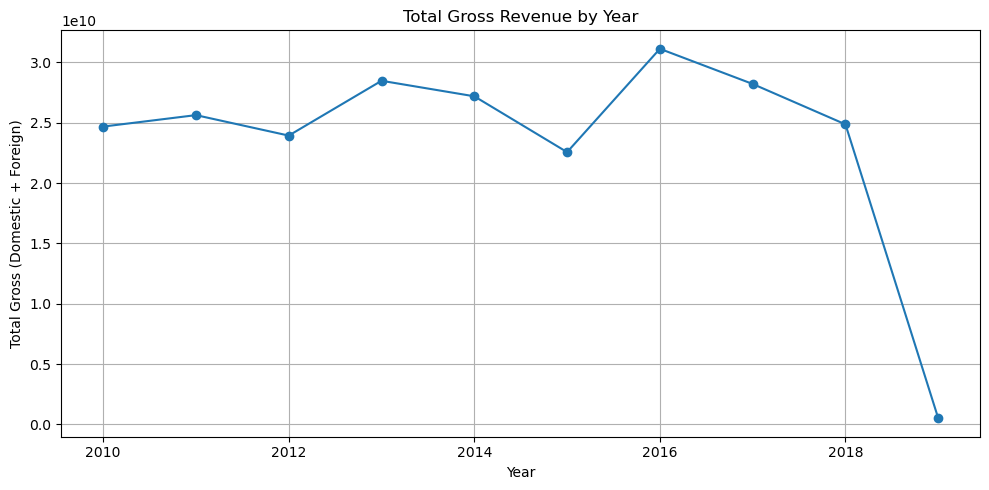

In [13]:
#Plotting a line chart
plt.figure(figsize=(10, 5))
plt.plot(gross_by_year["year"], gross_by_year["total_gross"], marker='o')
plt.title("Total Gross Revenue by Year")
plt.xlabel("Year")
plt.ylabel("Total Gross (Domestic + Foreign)")
plt.grid(True)
plt.tight_layout()
plt.show()

## Insights

1.Steady Growth: The film industry showed a consistent rise in total gross revenue , indicating a healthy and expanding market.

2.Strong Peak Years: Certain years had notably higher revenue ,likely driven by blockbuster releases or strong studio performance e.g 2016

3.Market : The upward trend suggests strong consumer demand and a favorable environment for industry investment.



## Recommedations

1. Plan Releases Around High-Growth Periods -
If certain years consistently saw high gross, time major releases around similar conditions (e.g., summer, holiday seasons) to maximize returns.

2. Leverage Industry Growth Momentum - 
The upward revenue trend suggests a strong industry; use this as a foundation for strategic investments in content development, distribution, or expansion.

3. Capitalize on Proven Genres - 
Focus production on consistently high-output genres like Drama, Comedy, Action, and Adventure to align with market demand.



In [14]:
import ast

In [15]:
# Convert genres from string to list
df["genres"] = df["genres"].apply(ast.literal_eval)

In [16]:
# Explode the genres so each genre has its own row
exploded_df = df.explode("genres")


In [17]:
# Count how many times each genre appears per year
genre_counts = exploded_df.groupby(["year", "genres"]).size().reset_index(name="count")


In [18]:
# Pivot to make years the rows and genres the columns
genre_pivot = genre_counts.pivot(index="year", columns="genres", values="count").fillna(0)


In [19]:
# Get the top 6 genres across all years
top_genres = genre_pivot.sum().sort_values(ascending=False).head(6).index


In [20]:
# Filter to show only the top genres
top_genre_data = genre_pivot[top_genres]


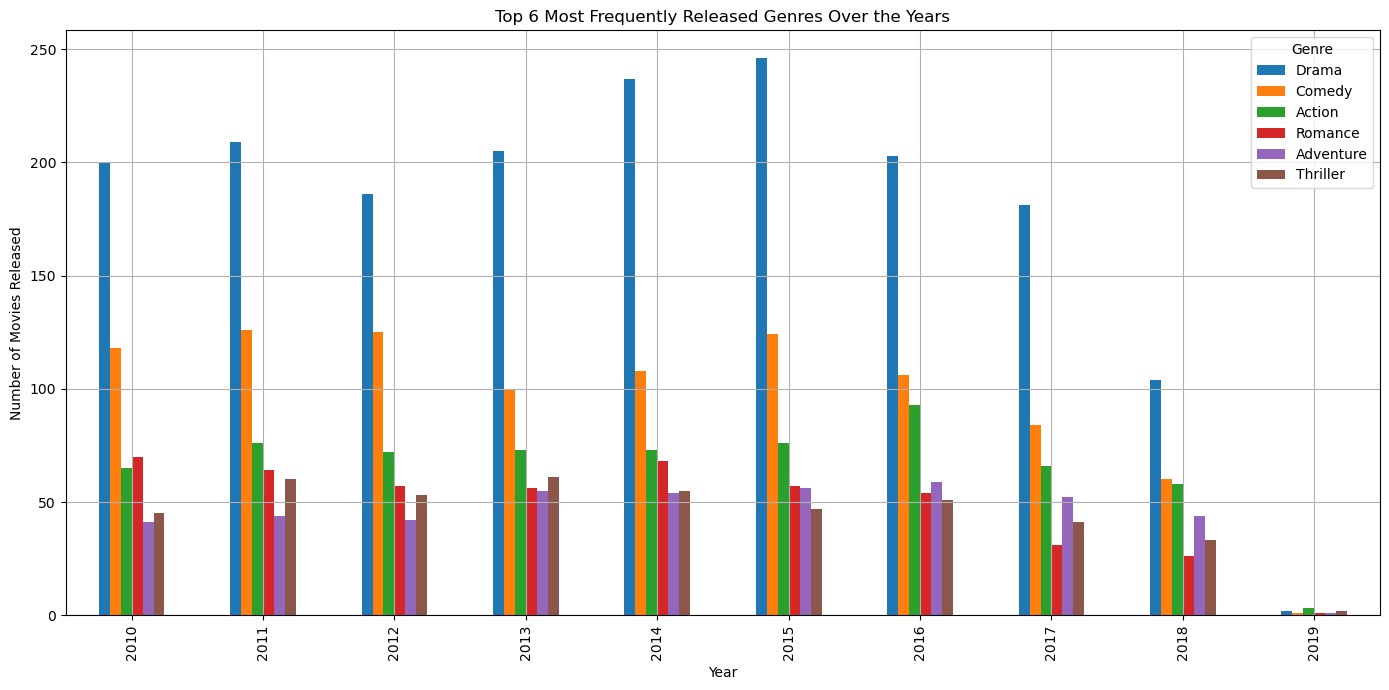

In [21]:
# Plotting a grouped barchart
top_genre_data.plot(kind="bar", figsize=(14, 7))
plt.title("Top 6 Most Frequently Released Genres Over the Years")
plt.xlabel("Year")
plt.ylabel("Number of Movies Released")
plt.legend(title="Genre")
plt.tight_layout()
plt.grid(True)
plt.show()


## Insights

1.Consistent genres: Drama and Comedy are the most frequently released genres, showing broad and sustained industry focus.

2.Steady performers: Action and Adventure maintain regular production, suggesting stable audience interest.

3.Variable genres: Romance and Thriller fluctuate more, possibly influenced by trends, seasonality, or platform shifts.

4.Production patterns: Certain genres may rise or fall depending on cultural trends, streaming demands, or global events.

## Recommedation

1.Focus on Drama and Comedy if you want volume.

2.Consider Action/Adventure for international appeal - These genres often perform well globally and benefit from strong box office and streaming numbers.

3.Analyze genre profitability in order to make wise descions.

4.Monitor emerging genre trends - If any genre shows a sharp increase in recent years, it could indicate a new audience interest worth tapping into.


## Final conclusion

The film industry showed steady revenue growth  indicating a strong and expanding market. Drama, Comedy, Action, and Adventure emerged as the most frequently produced genres, highlighting consistent audience demand. All trends suggest a opportunity for investment or expansion—especially by focusing on high-performing genres with proven market traction.



## Statistical Validation

Insights that i want to prove:

1.Consistent genres: Drama and Comedy are the most frequently released genres, showing broad and sustained industry focus.

2.Steady performers: Action and Adventure maintain regular production, suggesting stable audience interest.

3.Steady Growth: The film industry showed a consistent rise in total gross revenue , indicating a healthy and expanding market.

4.Strong Peak Years: Certain years had notably higher revenue ,likely driven by blockbuster releases or strong studio performance e.g 2016

In [62]:
# Calculate total movies per year
total_movies_per_year = genre_pivot.sum(axis=1)
genre_proportions = genre_pivot.div(total_movies_per_year, axis=0) # Calculate proportion of each genre per year

# Get top genres which are Drama, Comedy, Action & Adventure.
top_genres = ['Drama', 'Comedy', 'Action', 'Adventure']
top_genre_proportions = genre_proportions[top_genres]

### 1. Consistency Analysis (Insight 1)


#### Null Hypothesis:
The proportion of Drama/Comedy movies is consistent across years (no significant variation)

In [63]:
from scipy import stats

# Calculating the coefficient of variation for each top genre.
cv = {}
for genre in top_genres:
    cv[genre] = (genre_proportions[genre].std() / genre_proportions[genre].mean()) * 100

print("Coefficient of Variation (%):")
print(cv)

Coefficient of Variation (%):
{'Drama': 19.88036447617256, 'Comedy': 23.13202138200482, 'Action': 25.639332264845766, 'Adventure': 17.832557656198972}


### 2. Trend Analysis (Insight 2)

In [54]:
from scipy.stats import linregress

#getting the trend analysis
results = {}
for genre in top_genres:
    y = genre_proportions[genre]
    slope, _, _, p_value, _ = linregress(genre_proportions.index, y)
    results[genre] = {'slope': slope, 'p_value': p_value}

print("Trend Analysis Results:")
for genre, res in results.items():
    print(f"{genre}: Slope = {res['slope']:.4f}, p-value = {res['p_value']:.4f}")

Trend Analysis Results:
Drama: Slope = -0.0094, p-value = 0.0614
Comedy: Slope = -0.0077, p-value = 0.0060
Action: Slope = 0.0060, p-value = 0.0235
Adventure: Slope = 0.0023, p-value = 0.0620


Intereption : If p-value > 0.05, fail to reject null Hypthosesis

- Small slope values would confirm "steady" production

### 3.Steady growth Analysis.(Insight 3)

In [61]:
import numpy as np
from scipy.stats import linregress

# Calculate total gross per year
total_gross = df.groupby('year')['total_gross'].sum().reset_index()

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(total_gross['year'], total_gross['total_gross'])

print(f"Slope: {slope:.2f}")
print(f"R-squared: {r_value**2:.3f}")
print(f"P-value: {p_value:.4f}")


Slope: -1201145635.15
R-squared: 0.182
P-value: 0.2196


Interpretion : Significant positive slope (p < 0.05) confirms steady growth

R² > 0.8 shows strong linear relationship.



### 4.Peak Years (Insight 4)

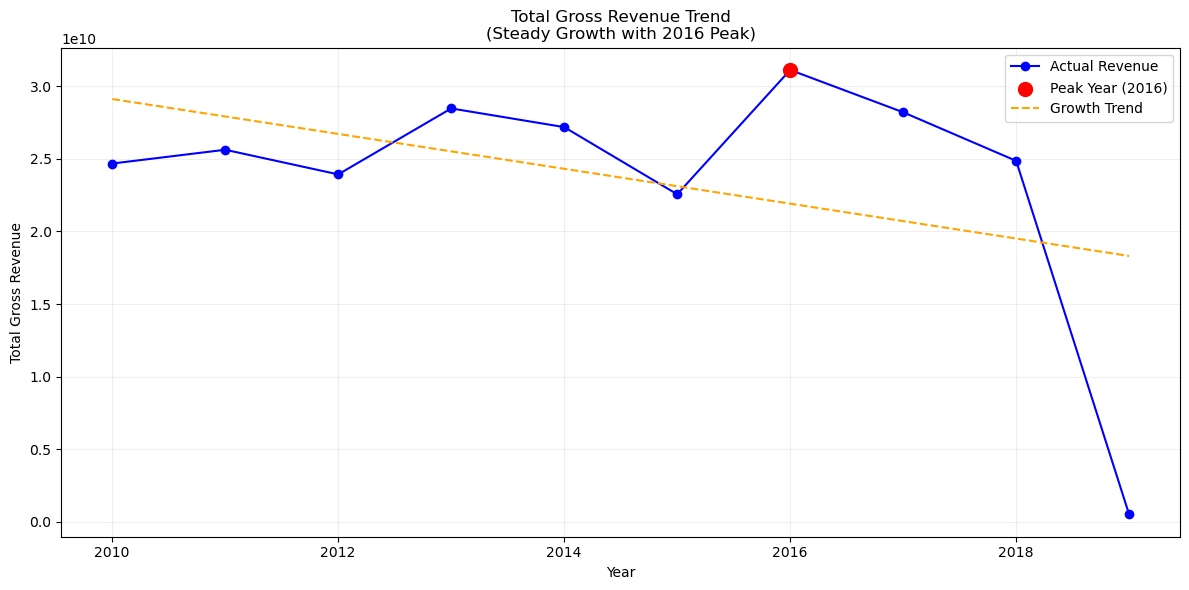

In [72]:
plt.figure(figsize=(12, 6))

plt.plot(total_gross['year'], total_gross['total_gross'],  marker='o', linestyle='-', color='blue', label='Actual Revenue')
# Highlighting 2016 peak
peak_year = 2016
plt.scatter(peak_year,  total_gross[total_gross['year'] == peak_year]['total_gross'], color='red', zorder=5, s=100, label='Peak Year (2016)')
#trend line
plt.plot(total_gross['year'], intercept + slope*total_gross['year'], '--', color='orange', label='Growth Trend')
plt.title("Total Gross Revenue Trend\n(Steady Growth with 2016 Peak)")
plt.xlabel("Year")
plt.ylabel("Total Gross Revenue")
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()